# 02 · Train EfficientNetV2-S
Thin driver over the shared engine — the ONLY difference between 02/03/04 is the model key.

In [14]:
# === Preamble 1/2: environment & GPU report ===
# This is a REMOTE Colab kernel — it cannot see your local files.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('bfloat16 supported:', torch.cuda.is_bf16_supported())
    else:
        print('No GPU — Runtime > Change runtime type > A100 (or L4).')
except ImportError:
    print('torch installs in the next cell.')

Python: 3.12.13
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
bfloat16 supported: True


In [15]:
# === Preamble 2/2: clone-or-pull + install (+ optional autoreload) ===
import os, subprocess, sys

REPO_URL = "https://github.com/Kidhurshan/plant-leaf-classifier.git"  # <-- EDIT to your repo
REPO_DIR = "/content/plant-leaf-classifier"
# Private repo? use https://<TOKEN>@github.com/Kidhurshan/plant-leaf-classifier.git

if not os.path.isdir(REPO_DIR):
    print('Cloning', REPO_URL)
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                'requirements.txt'], check=True)

# Hot-reload src/ after a `git pull` (optional convenience; never fatal).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _ip.run_line_magic('load_ext', 'autoreload')
    _ip.run_line_magic('autoreload', '2')
    print('autoreload enabled.')
except Exception as _e:
    print('autoreload not enabled (non-fatal):', repr(_e))

from src.utils import sync_repo, gpu_report
sync_repo()   # git pull + print the commit hash these results are traceable to
gpu_report()

autoreload not enabled (non-fatal): ModuleNotFoundError("No module named 'imp'")
Syncing repository (git pull)...
Already up to date.
Now running code at commit: e490cfd [DIRTY WORKING TREE]
ENVIRONMENT
  Python        : 3.12.13
  PyTorch       : 2.11.0+cu128
  CUDA available: True
  GPU           : NVIDIA A100-SXM4-40GB
  VRAM          : 39.5 GB
  CUDA runtime  : 12.8
  bfloat16      : YES


{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'vram_gb': 39.5,
 'cuda_version': '12.8',
 'bf16_supported': True}

## Why this architecture
**EfficientNetV2-S** is a CNN that uses *fused-MBConv* blocks in early stages for faster training and a compound width/depth/resolution scaling rule. Pretrained on ImageNet-21k then fine-tuned on 1k, it is our strong, fast **CNN baseline**.

## Config, model summary & shape check

In [16]:
from src.config import load_config
from src.utils import set_seed, detect_amp
from src.models import build_model, describe_model
import torch

SMOKE = False   # True -> ~200 imgs, 1+1 epochs, <5 min (needs nb 01 smoke cache)
MODEL = 'efficientnetv2s'
cfg = load_config('configs/default.yaml')
cfg.paths.ensure_dirs()
set_seed(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_m = build_model(cfg, MODEL, device=device)
print(describe_model(_m))
with torch.no_grad():
    _o = _m(torch.randn(2, 3, cfg.data.img_size, cfg.data.img_size, device=device))
assert tuple(_o.shape) == (2, cfg.data.num_classes), _o.shape
print('shape check OK:', tuple(_o.shape))
del _m  # train_model builds its own fresh copy

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


01:35:18 | INFO    | Built 'efficientnetv2s' (backbone=tf_efficientnetv2_s.in21k_ft_in1k, cbam=False): 20.2M params (20.2M trainable).
Backbone      : tf_efficientnetv2_s.in21k_ft_in1k
CBAM          : False (0 module(s))
Feature dim   : 1280
Total params  : 20,190,296 (20.2M)
Trainable     : 20,190,296 (20.2M)
Top-level modules:
  - backbone       EfficientNet            20.2M params
  - cbam_modules   ModuleList                  0 params
  - head           SharedHead              12.8K params
shape check OK: (2, 8)


## Preview one augmented image

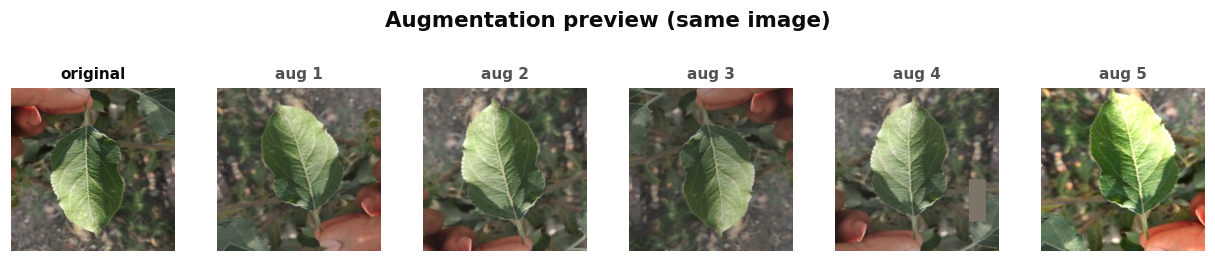

In [17]:
from src.data import prepare_datasets
from src.augment import GPUAugment, denormalize
from src import viz
datasets, class_names = prepare_datasets(cfg, device, smoke=SMOKE)
aug = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)
one = datasets['train'].images[datasets['train'].indices[0]].unsqueeze(0)
viz.plot_augmentation_preview(viz.to_hwc_uint8(one[0]),
                              [denormalize(aug(one))[0] for _ in range(5)]);

## Train — phase 1 (frozen backbone) then phase 2 (fine-tune all)
Watch the live per-epoch log; a total-runtime estimate prints after epoch 1.

In [18]:
from src.engine import train_model
res = train_model(cfg, MODEL, datasets, device, smoke=SMOKE,
                  class_names=class_names)
print('Best val macro-F1:', round(res['best_val_macro_f1'], 4))

01:35:45 | INFO    | Built 'efficientnetv2s' (backbone=tf_efficientnetv2_s.in21k_ft_in1k, cbam=False): 20.2M params (20.2M trainable).
01:35:45 | INFO    | Train class counts: [363, 238, 356, 364, 383, 328, 369, 111]
01:35:45 | WARNING | Ignoring checkpoint efficientnetv2s_last.pt: it was trained on a DIFFERENT data split (fingerprint None != 036e5075de42). Training 'efficientnetv2s' FROM SCRATCH.
  >> Split changed since that checkpoint -> training 'efficientnetv2s' from scratch (old checkpoint ignored).

=== efficientnetv2s: PHASE 1 (frozen backbone, 5 epochs) ===
  [P1 E01] train_loss=0.3127 val_loss=0.0337 val_acc=0.9833 val_f1=0.9787 lr=1.00e-03 (54.8s)
    * new best macro-F1=0.9787 -> saved efficientnetv2s_best.pt
  >> Estimated total training time: ~36m 32s (40 planned epochs @ 54.8s/epoch).
  [P1 E02] train_loss=0.0398 val_loss=0.0183 val_acc=0.9870 val_f1=0.9837 lr=1.00e-03 (1.8s)
    * new best macro-F1=0.9837 -> saved efficientnetv2s_best.pt
  [P1 E03] train_loss=0.0272 val

## Training curves (visual 4)

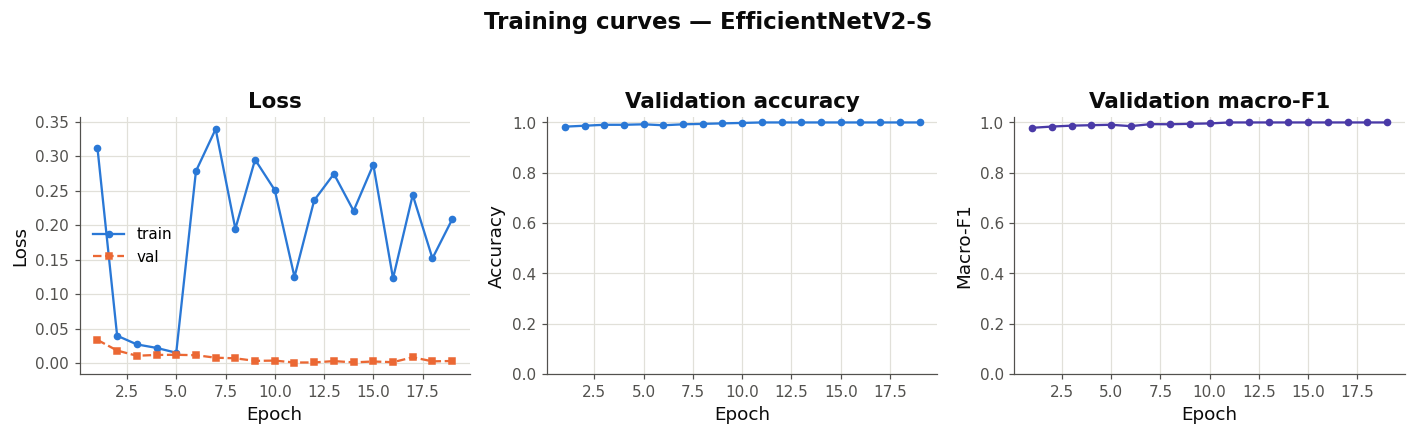

In [19]:
viz.plot_training_curves(res['history'], MODEL,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_curves.png");

## Validation confusion matrix

01:38:18 | INFO    | Eval: acc=1.0000 macro-F1=1.0000
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        78
       berry     1.0000    1.0000    1.0000        51
         fig     1.0000    1.0000    1.0000        76
       guava     1.0000    1.0000    1.0000        78
      orange     1.0000    1.0000    1.0000        82
        palm     1.0000    1.0000    1.0000        70
   persimmon     1.0000    1.0000    1.0000        79
      tomato     1.0000    1.0000    1.0000        24

    accuracy                         1.0000       538
   macro avg     1.0000    1.0000    1.0000       538
weighted avg     1.0000    1.0000    1.0000       538



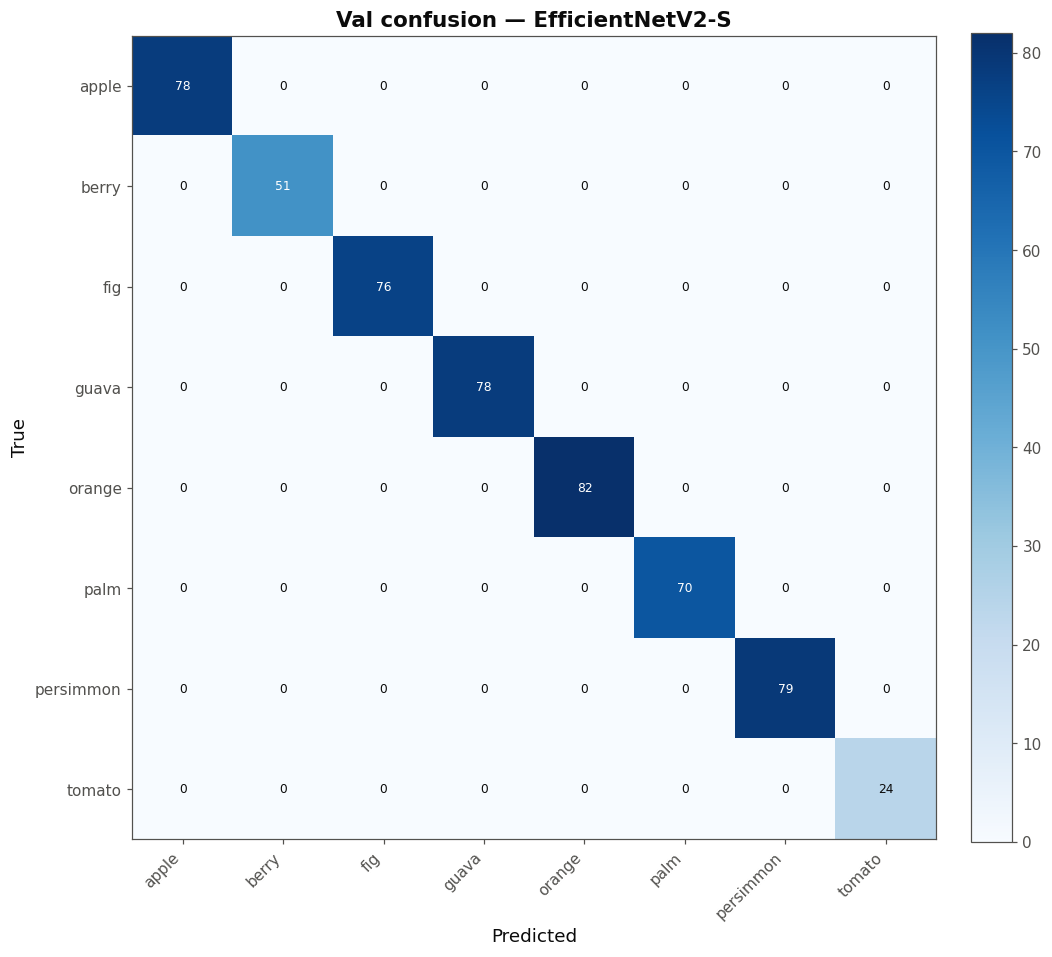

In [20]:
from src.evaluate import evaluate_model
from src.utils import detect_amp
aug_eval = GPUAugment(cfg.augment, cfg.data.img_size, device, training=False)
bs = cfg.smoke.batch_size if SMOKE else cfg.train.batch_size
m = evaluate_model(res['model'], datasets['val'], aug_eval,
                   detect_amp(device), bs, class_names)
viz.plot_confusion_matrix(m['confusion_matrix'], class_names,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_val_confusion.png",
    title=f'Val confusion — {viz.display_name(MODEL)}')
print(m['report'])

## Outputs

In [21]:
print('checkpoint ->', res['best_checkpoint'])
print('history    ->', res['history_csv'])
print('figures    ->', cfg.paths.figures_dir)

checkpoint -> checkpoints/efficientnetv2s_best.pt
history    -> results/metrics/efficientnetv2s_history.csv
figures    -> results/figures


---
### ⚠️ When finished: disconnect and DELETE the runtime
`Runtime > Disconnect and delete runtime`. Colab compute units are consumed the whole time a runtime is connected.